In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def simulator(a, b, c, d, x):
    noise = np.random.normal(0, 1)
    y = a * np.sin(b * x) + c * (x**2) + d + noise
    return y

In [3]:
np.random.seed(42)

n_samples = 1000

data = []

for _ in range(n_samples):
    a = np.random.uniform(0.5, 5)
    b = np.random.uniform(0.1, 2)
    c = np.random.uniform(-2, 2)
    d = np.random.uniform(-5, 5)
    x = np.random.uniform(0, 10)

    y = simulator(a, b, c, d, x)

    data.append([a, b, c, d, x, y])

df = pd.DataFrame(data, columns=['a', 'b', 'c', 'd', 'x', 'y'])
df.head()

,a,b,c,d,x,y
0,2.185431,1.906357,0.927976,0.986585,1.560186,3.888450
1,3.686327,0.139111,1.879639,3.324426,2.123391,13.882964
2,1.318212,0.448469,-0.783031,0.247564,4.319450,-12.314768
3,1.127722,0.655075,-0.534553,-0.439300,7.851760,-35.942957
4,1.398532,1.077045,0.369658,-4.535496,6.075449,8.868741


In [4]:
X = df[['a', 'b', 'c', 'd', 'x']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
results_df.sort_values(by="R2", ascending=False)

,Model,MSE,R2
7,Gradient Boosting,24.729703,0.990697
4,Random Forest,25.378652,0.990453
3,Decision Tree,74.354223,0.972030
5,KNN,276.917041,0.895832
2,Lasso,1265.792758,0.523847
1,Ridge,1275.678968,0.520128
0,Linear Regression,1275.767550,0.520095
6,SVR,1804.267441,0.321289


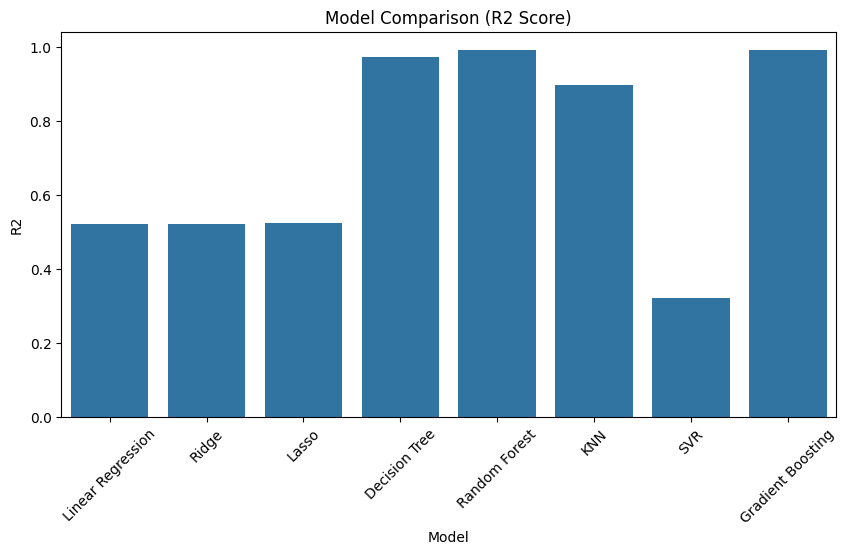

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="R2", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()